In [1]:
import sys
sys.path.insert(1,'..')
from evo_sim import evo_sim
import numpy as np
import matplotlib.pyplot as plt

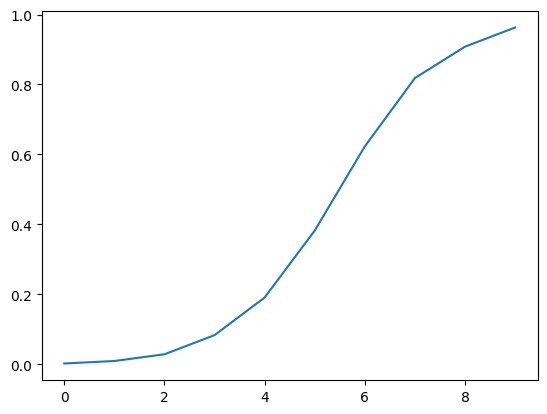

In [2]:
theta = np.array([-2.,-2.,-2.,-5.,-8.,-7.])
y = evo_sim(theta)

plt.plot(y[0:10])

In [3]:
from inference_utils import get_prior
import torch
prior = get_prior('EVO_SIM')

def EVO_SIM_wrapper(reps, parameters, seed=None):
    evo_reps = torch.empty(reps, 30)
    for i in range(reps):
        out=evo_sim(parameters)
        evo_reps[i,:] = torch.tensor(out)
    return evo_reps

In [3]:
# Test set
N = 200
theta_test = prior.sample((N,))
x_test = torch.empty(N,10, 30)
for i in range(N):
    x_test[i] = EVO_SIM_wrapper(10, theta_test[i])


torch.save(x_test, 'x_test.pt')
torch.save(theta_test, 'theta_test.pt')

NameError: name 'prior' is not defined

In [13]:
# Hierarchical noisy test set
theta_test = torch.load('theta_test.pt')
N = len(theta_test)
x_test_h = torch.load('x_test_h.pt')

for i in range(N):
    # pert = torch.normal(mean=0, std=0.1, size=(7, 6))
    # outliers = torch.normal(mean=0, std=1, size=(3, 6))
    # for j in range(10):
    #     if j < 7:
    #         x_test_h[i, j] = torch.from_numpy(evo_sim(theta_test[i] + pert[j]))
    #     else:
    #         x_test_h[i, j] = torch.from_numpy(evo_sim(theta_test[i] + outliers[j-7]))

    # add guassian noise with mu=0, sigma=0.1X
    x_test_h[i] = x_test_h[i] + torch.normal(mean=0, std=0.1*x_test_h[i])
    # clamp between 0 and 1
    x_test_h[i] = torch.clamp(x_test_h[i], 0, 1)

torch.save(x_test_h, 'x_test_r.pt')


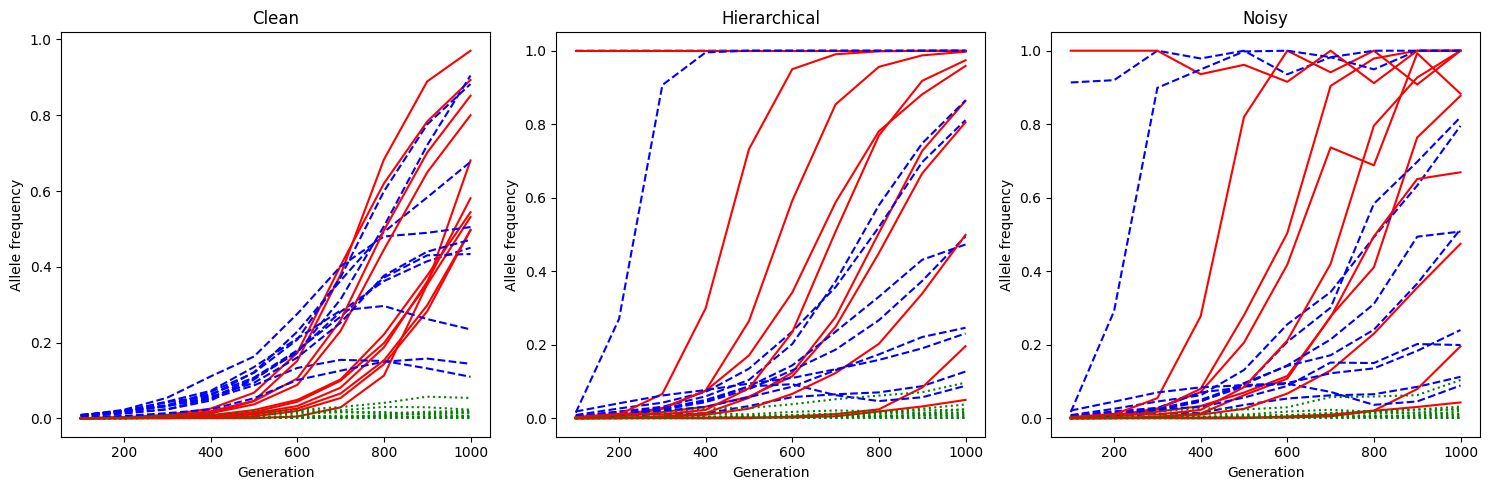

In [15]:
# plot x_test, x_test_h, x_test_r at pos 0
# obs is 10,30
# use 3 axes
from evo_sim import plot_vec30

x_test = torch.load('x_test.pt')
x_test_h = torch.load('x_test_h.pt')
x_test_r = torch.load('x_test_r.pt')

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

t = 0
for i in range(10):
    plot_vec30(ax=ax[0], vec30=x_test[t, i], title="Clean")
    plot_vec30(ax=ax[1], vec30=x_test_h[t, i], title="Hierarchical")
    plot_vec30(ax=ax[2], vec30=x_test_r[t, i], title="Noisy")
